# Лабораторная работа №2: Обнаружение аномалий и выбросов в  данных
### Задание 1. Загрузка и профилирование данных

Размер датасета: 1000 строк, 9 столбцов
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB
Количество пропусков по столбцам:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
Диапазон числовых значение:
                Минимальное:   Максимальное:   Диап

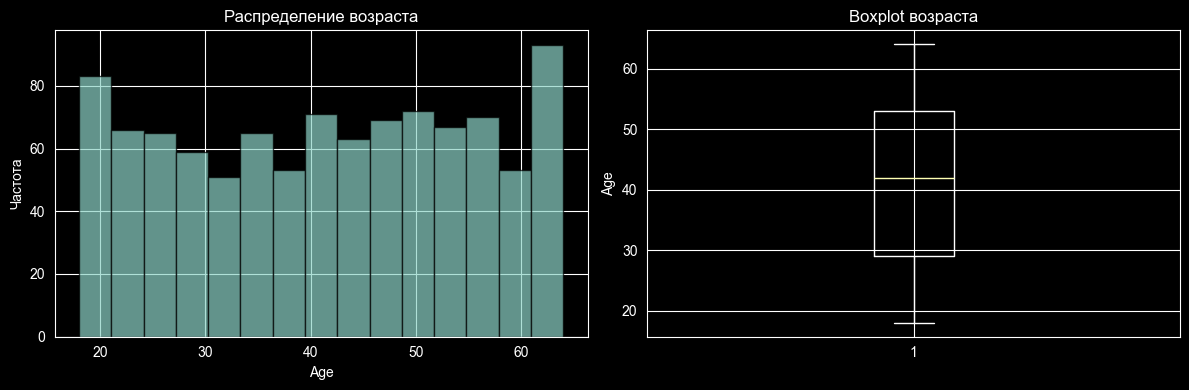

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/retail_sales_dataset.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

# Информация о столбцах и типах
df.info()
# Статистика по числовым признакам
df.describe()

print('Количество пропусков по столбцам:')
print(df.isnull().sum())

print('Диапазон числовых значение:')
number_col = df.select_dtypes(include='number')
result_range = pd.DataFrame({
    'Минимальное: ' : number_col.min(),
    'Максимальное: ' : number_col.max(),
    'Диапазон: ' : number_col.max() - number_col.min()
})
print(result_range)

def find_extremes_percentile(data, column, percentile=1):
    lower_thresh = data[column].quantile(percentile / 100)
    upper_thresh = data[column].quantile(1 - percentile / 100)

    extremes = data[(data[column] <= lower_thresh) | (data[column] >= upper_thresh)]
    return  extremes, lower_thresh, upper_thresh
for column in number_col.columns:
    extremes_1, lower_1, upper_1 = find_extremes_percentile(df, column, 1)
    print('Столбец: ', column)
    print(f'Экстремальные (1%): от {lower_1} до {upper_1}')
    print(f"Количество экстремальных значений: {len(extremes_1)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Возраст
# Гистограмма
axes[0].hist(df['Age'], bins=15, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение возраста')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Частота')
# Boxplot
axes[1].boxplot(df['Age'])
axes[1].set_title('Boxplot возраста')
axes[1].set_ylabel('Age')
plt.tight_layout()
plt.show()

#### Вывод о возможных выбросах
- Гистограмма: примерно равномерное распределение с небольшим смещением в сторону старших возрастов
- Boxplot: выбросов не обнаружено - все точки в пределах усов

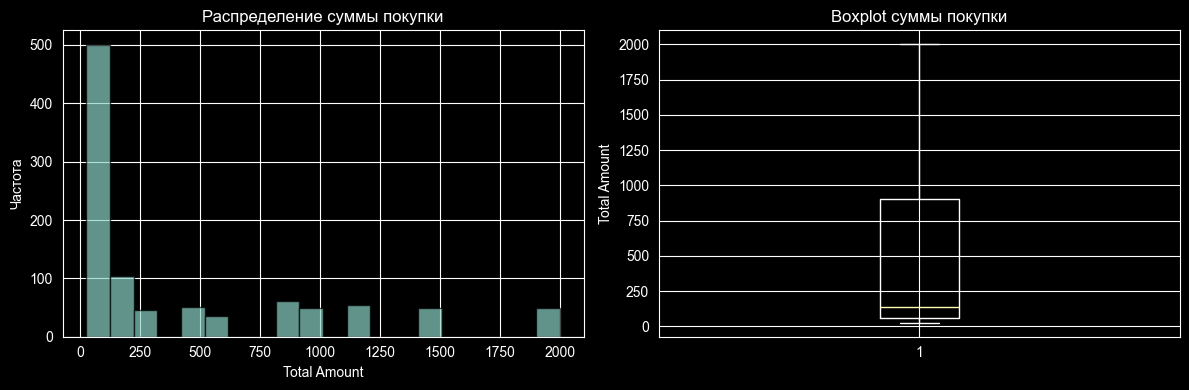

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Гистограмма
axes[0].hist(df['Total Amount'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение суммы покупки')
axes[0].set_xlabel('Total Amount')
axes[0].set_ylabel('Частота')
# Boxplot
axes[1].boxplot(df['Total Amount'])
axes[1].set_title('Boxplot суммы покупки')
axes[1].set_ylabel('Total Amount')
plt.tight_layout()
plt.show()

#### Вывод о возможных выбросах
- Гистограмма: распределение сильно скошено вправо — большинство покупок на небольшие суммы (25-300)
- Boxplot: выбросов не обнаружено - все точки в пределах усов

### Задание 2. Проверка нормальности распределения

Описательные характеристики:
         Строка  Среднее  Медиана  Стандартное отклонение  \
0           Age   41.392     42.0               13.681430   
1  Total Amount  456.000    135.0              559.997632   

   Коэффицент асимметрии  Коэффицент эксцесса  
0              -0.048739            -1.201208  
1               1.374063             0.804968  


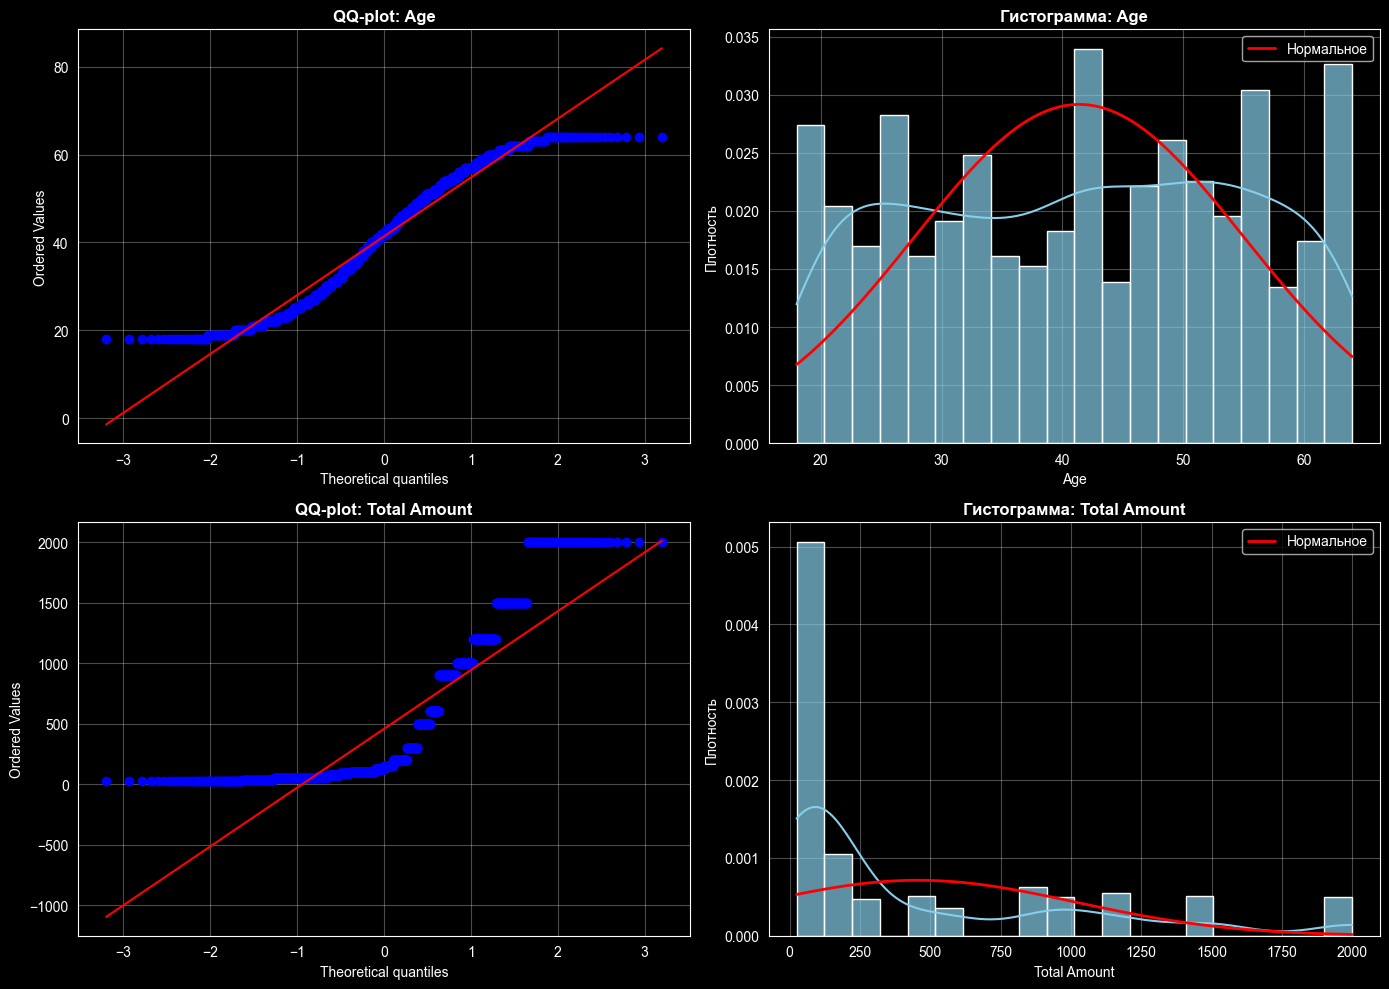

In [6]:
from scipy import stats
import numpy as np
features = ['Age', 'Total Amount']
print('Описательные характеристики:')
specifications_result = []
for feature in features:
    specifications_result.append({
        'Строка' : feature,
        'Среднее' : df[feature].mean(),
        'Медиана' : df[feature].median(),
        'Стандартное отклонение' : df[feature].std(),
        'Коэффицент асимметрии' : stats.skew(df[feature]),
        'Коэффицент эксцесса' : stats.kurtosis(df[feature])
    })
print(pd.DataFrame(specifications_result))


# Создание графиков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(features):
    # QQ-plot
    stats.probplot(df[feature], dist="norm", plot=axes[idx, 0])
    axes[idx, 0].set_title(f'QQ-plot: {feature}', fontsize=12, fontweight='bold')
    axes[idx, 0].grid(True, alpha=0.3)

    # Гистограмма с кривой нормального распределения
    sns.histplot(data=df, x=feature, bins=20, kde=True,
                 stat='density', alpha=0.7, color='skyblue', ax=axes[idx, 1])

    # Кривая нормального распределения
    mu, std = df[feature].mean(), df[feature].std()
    x = np.linspace(df[feature].min(), df[feature].max(), 100)
    axes[idx, 1].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Нормальное')

    axes[idx, 1].set_title(f'Гистограмма: {feature}', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel(feature)
    axes[idx, 1].set_ylabel('Плотность')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



#### Age:
- QQ-график имеет S-образную форму
- Плосковершинное распределение
- График не совпадает с графиком нормального распределения
#### Total Amount:
- QQ-график сильно изогнут вверх
- Правосторонняя асимметрия
- График не совпадает с графиком нормального распределения

In [9]:
features = ['Age', 'Total Amount']
# Уровень значимости
alpha = 0.05
print("ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ (КРИТЕРИЙ ШАПИРО-УИЛКА)")

print("\nГИПОТЕЗЫ:")
print("   H₀: выборка подчиняется нормальному распределению")
print("   H₁: выборка НЕ подчиняется нормальному распределению")
print(f"\n   Уровень значимости α = {alpha}")
print(f"   Правило: если p-value < {alpha} → отвергаем H₀")

for feature in features:
    # Критерий Шапиро-Уилка
    statistic, p_value = stats.shapiro(df[feature])

    print(f"\n {feature}:")
    print(f"   • Статистика W = {statistic:.6f}")
    print(f"   • p-value = {p_value}")

    if p_value < alpha:
        print(f"   • Результат: p-value ({p_value}) < {alpha}")
        print(f"   • Решение: ОТВЕРГАЕМ H₀")
        print(f"   • Вывод: Распределение {feature} НЕ является нормальным")
    else:
        print(f"   • Результат: p-value ({p_value}) ≥ {alpha}")
        print(f"   • Решение: НЕТ ОСНОВАНИЙ ОТВЕРГНУТЬ H₀")
        print(f"   • Вывод: Распределение {feature} может быть нормальным")

ПРОВЕРКА НОРМАЛЬНОСТИ РАСПРЕДЕЛЕНИЯ (КРИТЕРИЙ ШАПИРО-УИЛКА)

ГИПОТЕЗЫ:
   H₀: выборка подчиняется нормальному распределению
   H₁: выборка НЕ подчиняется нормальному распределению

   Уровень значимости α = 0.05
   Правило: если p-value < 0.05 → отвергаем H₀

 Age:
   • Статистика W = 0.952415
   • p-value = 1.8233998212466617e-17
   • Результат: p-value (1.8233998212466617e-17) < 0.05
   • Решение: ОТВЕРГАЕМ H₀
   • Вывод: Распределение Age НЕ является нормальным

 Total Amount:
   • Статистика W = 0.748911
   • p-value = 2.1785847545499362e-36
   • Результат: p-value (2.1785847545499362e-36) < 0.05
   • Решение: ОТВЕРГАЕМ H₀
   • Вывод: Распределение Total Amount НЕ является нормальным


### Задание 3. Обнаружение выбросов статистическими методами
#### 1. Метод Z-score

ОБНАРУЖЕНИЕ ВЫБРОСОВ МЕТОДОМ Z-SCORE
Признак: Age
   Среднее (μ): 41.39
   Стандартное отклонение (σ): 13.68
Оценка Z-score для Age:
0     -0.540294
1     -1.125029
2      0.629174
3     -0.321019
4     -0.832662
         ...   
995    1.506275
996    0.775358
997   -1.344304
998   -0.394111
999    0.409899
Name: Age, Length: 1000, dtype: float64

ОПРЕДЕЛЕНИЕ ВЫБРОСОВ
   Пороговое значение: |Z| > 3
   Нижняя граница: 0.34771102263242426
   Верхняя граница: 82.43628897736758
   Количество выбросов: 0 (0.00%)


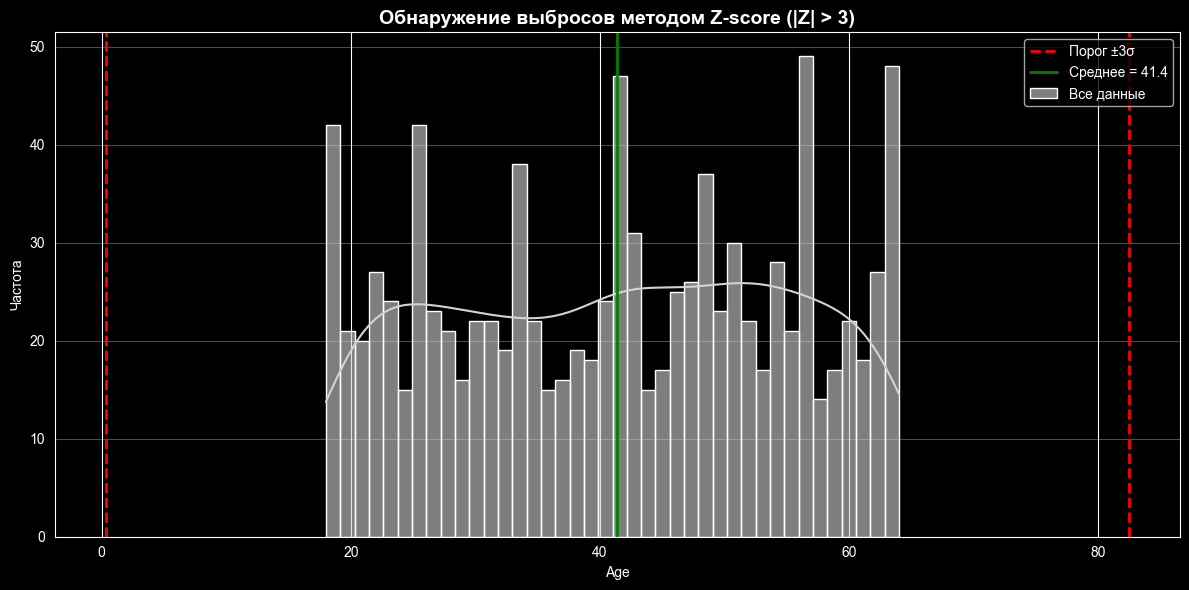

In [17]:
feature = 'Age'
data = df[feature]
print("ОБНАРУЖЕНИЕ ВЫБРОСОВ МЕТОДОМ Z-SCORE")
print(f"Признак: {feature}")
# Расчет среднего и стандартного отклонения
mean_val = data.mean()
std_val = data.std()
print(f"   Среднее (μ): {mean_val:.2f}")
print(f"   Стандартное отклонение (σ): {std_val:.2f}")
# Расчет Z-оценок: z = (x - μ) / σ
z_scores = (data - mean_val) / std_val
print(f'Оценка Z-score для {feature}:')
print(z_scores)

print("\nОПРЕДЕЛЕНИЕ ВЫБРОСОВ")
threshold = 3
outliers_mask = np.abs(z_scores) > threshold
outliers_count = outliers_mask.sum()
outliers_values = data[outliers_mask].values
outliers_percentage = (outliers_count / len(data)) * 100
lower_bound = mean_val - threshold * std_val
upper_bound = mean_val + threshold * std_val
print(f"   Пороговое значение: |Z| > {threshold}")
print(f"   Нижняя граница: {lower_bound}")
print(f"   Верхняя граница: {upper_bound}")
print(f"   Количество выбросов: {outliers_count} ({outliers_percentage:.2f}%)")


outlier_data = data[outliers_mask]
plt.figure(figsize=(12, 6))
sns.histplot(data, bins=40, kde=True, color='lightgray', alpha=0.6, label='Все данные')
# Выделение выбросов
if outliers_count > 0:
    plt.hist(outlier_data, bins=10, color='red', alpha=0.8,
             label=f'Выбросы: {outliers_count} ({outliers_percentage:.2f}%)')
plt.axvline(lower_bound, color='red', linestyle='--', linewidth=2,
            label=f'Порог ±3σ')
plt.axvline(upper_bound, color='red', linestyle='--', linewidth=2)
plt.axvline(mean_val, color='green', linestyle='-', linewidth=2,
            label=f'Среднее = {mean_val:.1f}')

plt.title(f'Обнаружение выбросов методом Z-score (|Z| > {threshold})',
          fontweight='bold', fontsize=14)
plt.xlabel(feature)
plt.ylabel('Частота')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Метод IQR

In [18]:
Q1 = df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('Q1: ', Q1)
print('Q3: ', Q3)
print('IQR: ', IQR)
print('Нижняя граница: ', lower_bound)
print('Верхняя граница: ', upper_bound)

outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
print(f'Выбросов по методу IQR: {len(outliers)}')

Q1:  29.0
Q3:  53.0
IQR:  24.0
Нижняя граница:  -7.0
Верхняя граница:  89.0
Выбросов по методу IQR: 0


#### Сравнение методов:
- Z-score: нижняя граница ≈ 0, верхняя граница ≈ 83, количество выбросов при |Z| > 3 = 0
- IQR: нижняя граница = -7, верхняя граница = 89, количество выбросов = 0
#### Cравнительный анализ методов:
##### Z-score, если:
- Распределение близко к нормальному
- Нужна стандартизация для дальнейшего анализа
- Нужно минимизировать ложные срабатывания
##### IQR, если:
- Распределение НЕ нормальное (скошено)
- Есть много выбросов
- Данные с устойчивыми статистиками